**Retail Sales Visualization, Relationship Analysis & Business Insights**


○ Construct bar plots and box plots using seaborn to visualize profit and sales distribution.

○ Plot discount levels against profit margins to identify discount thresholds that ruin profitability.

○ Generate a correlation heatmap across all numerical attributes.

○ Prepare the findings into a 1-page survey report.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/superstore_raw.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,consumer,United States,HENDERSON,...,42420,South,FUR-BO-10001798,furniture,bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,CONSUMER,United States,Henderson,...,42420,South,FUR-CH-10000454,FURNITURE,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,LOS ANGELES,...,90036,West,OFF-LA-10000240,Office Supplies,labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,OFFICE SUPPLIES,storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(100, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [7]:
df[["Sales", "Quantity", "Discount", "Profit", "Category", "Sub-Category", "Region"]].head(10)

,Sales,Quantity,Discount,Profit,Category,Sub-Category,Region
0,261.9600,2,0.00,41.9136,furniture,bookcases,South
1,731.9400,3,0.00,219.5820,FURNITURE,Chairs,South
2,14.6200,2,0.00,6.8714,Office Supplies,labels,West
3,957.5775,5,0.45,-383.0310,Furniture,Tables,South
4,22.3680,2,0.20,2.5164,OFFICE SUPPLIES,storage,South
5,48.8600,7,0.00,14.1694,Furniture,Furnishings,West
6,7.2800,4,0.00,1.9656,office supplies,Art,West
7,907.1520,6,0.20,90.7152,technology,phones,West
8,18.5040,3,0.20,5.7825,Office Supplies,Binders,West
9,114.9000,5,0.00,34.4700,OFFICE SUPPLIES,Appliances,West


In [8]:
df['Category']=df['Category'].str.title()
df['Sub-Category']=df['Sub-Category'].str.title()
df['Region']=df['Region'].str.title()

In [9]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='mixed',
    errors='coerce'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='mixed',
    errors='coerce'
)

In [10]:
print(df['Order Date'].dtypes)
print(df['Ship Date'].dtypes)

datetime64[ns]
datetime64[ns]


In [11]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [12]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [13]:
df.duplicated().sum()

np.int64(0)

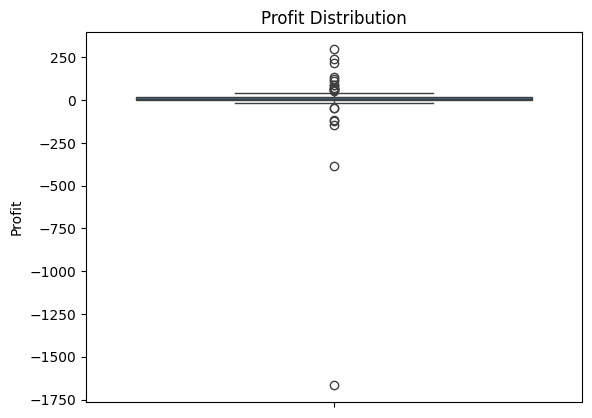

In [14]:
sns.boxplot(y=df["Profit"])

plt.title("Profit Distribution")
plt.ylabel("Profit")

plt.show()


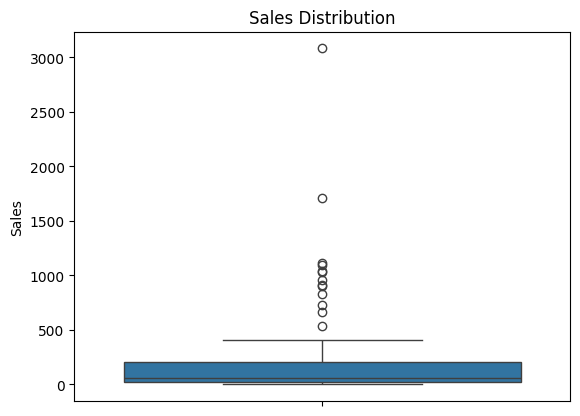

In [15]:
sns.boxplot(y=df["Sales"])

plt.title("Sales Distribution")
plt.ylabel("Sales")

plt.show()

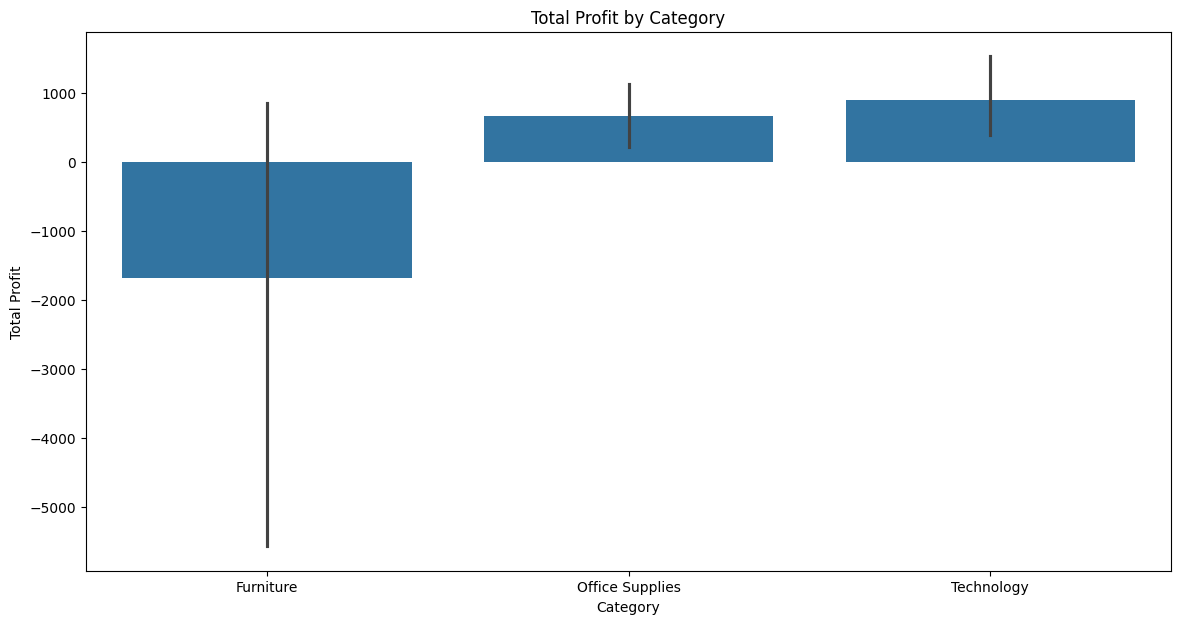

In [16]:
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df,
    x="Category",
    y="Profit",
    estimator="sum"
)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

In [17]:
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum()

subcategory_profit

,Profit
Sub-Category,
Accessories,52.7433
Appliances,5.0888
Art,145.7102
Binders,223.4431
Bookcases,-1670.1150
Chairs,131.2134
Envelopes,99.3241
Fasteners,6.2566
Furnishings,-54.9878


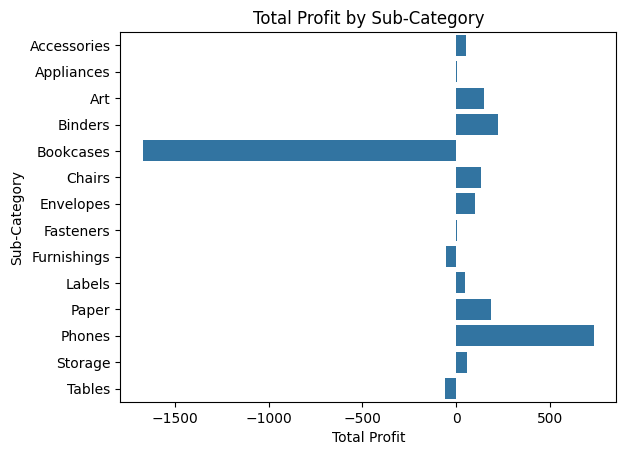

In [18]:
sns.barplot(
    x=subcategory_profit.values,
    y=subcategory_profit.index
)

plt.title("Total Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.show()

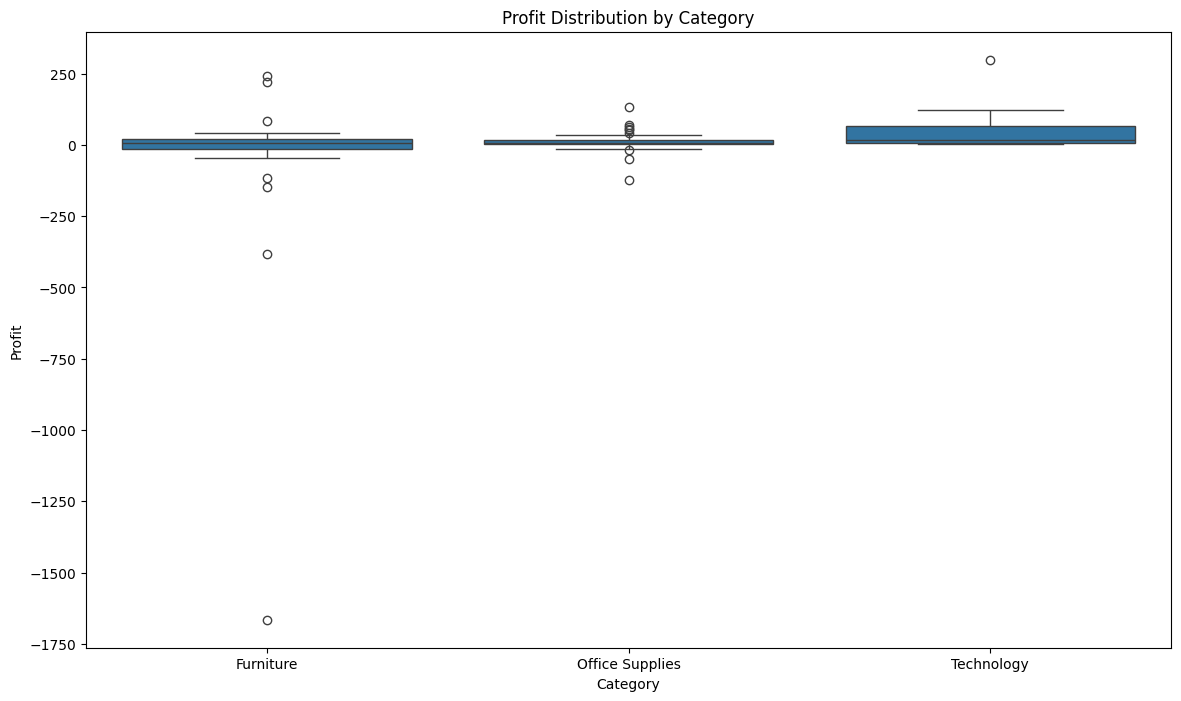

In [19]:
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

In [20]:
region_profit = df.groupby("Region")["Profit"].sum()

region_profit

,Profit
Region,
Central,66.0586
East,-1188.4077
South,-39.4633
West,1059.9217


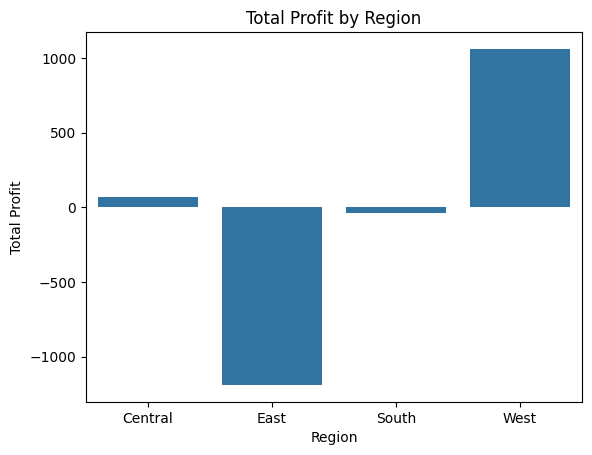

In [21]:
sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

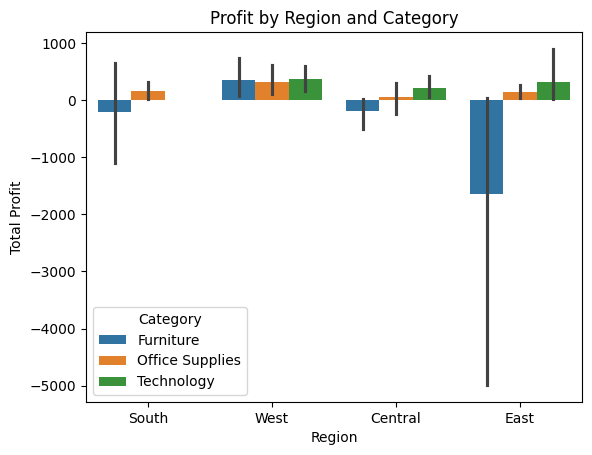

In [22]:
sns.barplot(
    data=df,
    x="Region",
    y="Profit",
    hue="Category",
    estimator="sum"
)

plt.title("Profit by Region and Category")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

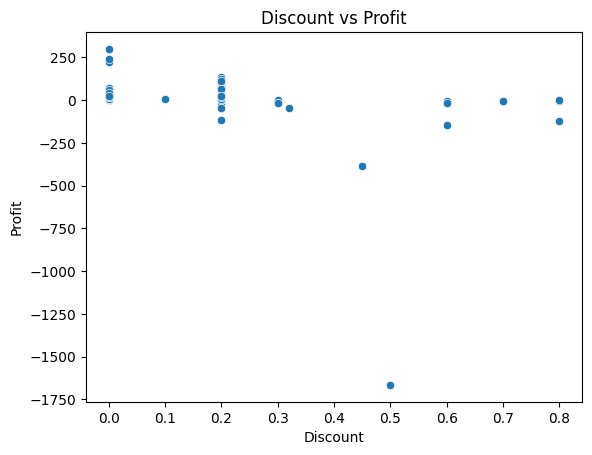

In [23]:
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [24]:
df["Discount"].unique()

array([0.  , 0.45, 0.2 , 0.8 , 0.3 , 0.5 , 0.7 , 0.6 , 0.32, 0.1 ])

In [25]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit

,Profit
Discount,
0.00,30.557200
0.10,7.098000
0.20,23.845274
0.30,-10.463033
0.32,-46.976400
0.45,-383.031000
0.50,-1665.052200
0.60,-56.087600
0.70,-5.518733


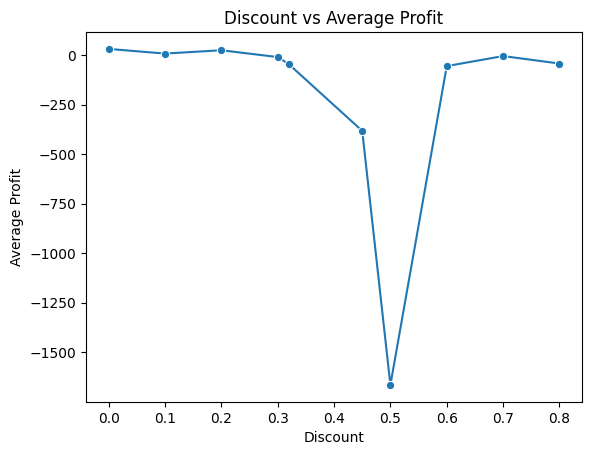

In [26]:
sns.lineplot(
    x=discount_profit.index,
    y=discount_profit.values,
    marker="o"
)

plt.title("Discount vs Average Profit")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.show()

In [27]:
numeric_data = df[
    ["Sales", "Quantity", "Discount", "Profit"]
]

In [28]:
correlation = numeric_data.corr()

correlation

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.412793,0.122386,-0.542119
Quantity,0.412793,1.000000,0.100989,-0.126887
Discount,0.122386,0.100989,1.000000,-0.283765
Profit,-0.542119,-0.126887,-0.283765,1.000000


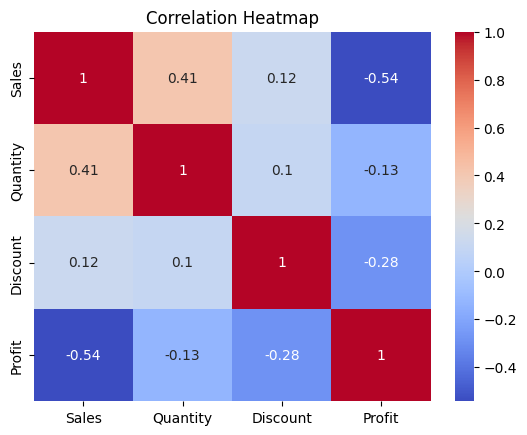

In [29]:
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [30]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

,Profit
Category,
Technology,903.6039
Office Supplies,671.9193
Furniture,-1677.4139


In [31]:
df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

,Profit
Sub-Category,
Phones,732.9252
Binders,223.4431
Paper,183.2701
Art,145.7102
Chairs,131.2134
Envelopes,99.3241
Storage,55.5314
Accessories,52.7433
Labels,45.1628


In [32]:
df.groupby("Discount")["Profit"].mean().sort_index()

,Profit
Discount,
0.00,30.557200
0.10,7.098000
0.20,23.845274
0.30,-10.463033
0.32,-46.976400
0.45,-383.031000
0.50,-1665.052200
0.60,-56.087600
0.70,-5.518733
